# Données multimédia : Python pour le traitement d’images et de données audio

## Master Humanités Numériques du [CESR](https://cesr.univ-tours.fr/)

Clément Plancq (MSH VDL / CITERES)

## Filtres et modifications d’image

Dans la séance précédente nous avons vu comment accéder aux informations d’une image, la convertir, la retailler, la faire pivoter.  
Aujourd’hui nous allons nous appliquer à modifier les images à l’aide notamment de filtres. Ils sont définis dans le module [`ImageFilter`](https://pillow.readthedocs.io/en/stable/reference/ImageFilter.html)



✏️ Avant d’attaquer cette partie, un petit échauffement avec des choses vues à la séance précédente : 
 1. faîtes pivoter l’image tête en bas, 
 2. passez la en niveaux de gris.

In [ ]:
# from PIL import Image
import matplotlib.pyplot as plt

# j’agrandis un peu la taille par défaut de la figure montrée par matplotlib
plt.rcParams['figure.figsize'] = [20, 10]

im = Image.open('../img/CPR_1130x400.jpg')

# insérez le code pour faire pivoter l’image 
im_flipped = 

# passage en niveaux de gris
im_flipped_gray =

plt.imshow(im_flipped_gray)

## Filtres de flou (*blur*)

Nous allons d’abord utiliser le filtre de type `Box Blur` (voir https://pillow.readthedocs.io/en/stable/reference/ImageFilter.html#PIL.ImageFilter.BoxBlur)

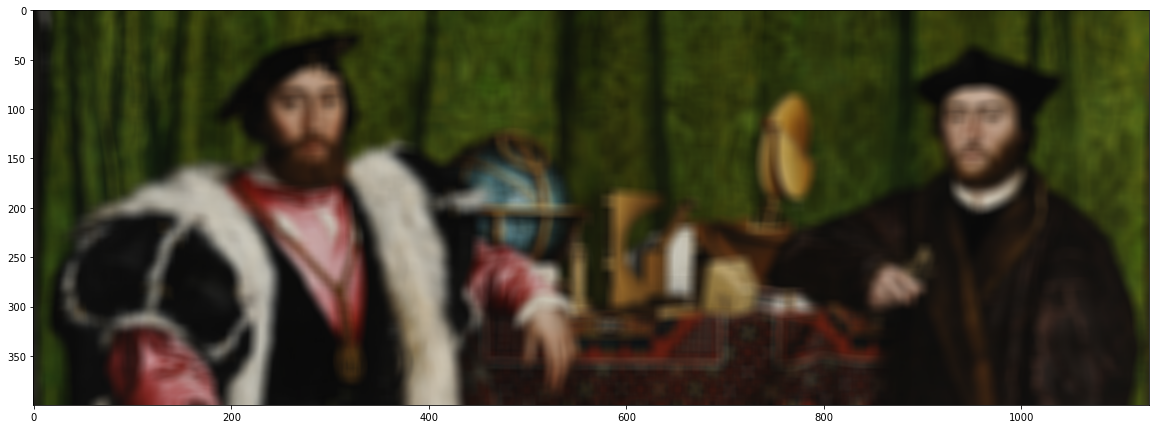

In [76]:
from PIL import ImageFilter


im_blur = im.filter(ImageFilter.BoxBlur(6))
plt.imshow(im_blur)

✏️ Faîtes varier le paramètre (le radius) jusqu’à arriver à un niveau de flou où on ne distingue plus rien

### Comment ça fonctionne ?

Pour comprendre comment fonctionne les filtres il faut comprendre ce qu’est un noyau (*kernel*) et ce qu’est une convolution.

Le principe général est qu’on va modifier la valeur d’un pixel en fonction de celle de ses voisins.

La convolution est une opération mathématique qui combine deux ensembles de données pour en créer un troisième.  Vous prenez une petite matrice (appelée filtre ou noyau) et la faites "glisser" sur toute l'image. À chaque position, vous multipliez les valeurs du filtre par les valeurs correspondantes de l'image, puis vous additionnez ces résultats.  
Le total obtenu est la nouvelle valeur pour la position actuelle dans l'image filtrée.

Cette visualisation permettra d’y voir plus clair : https://setosa.io/ev/image-kernels/


Exemple de noyau (3x3) pour le Box Blur
$$
\frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1 \\
\end{bmatrix}
$$

D’autres exemples de noyaux : https://fr.wikipedia.org/wiki/Noyau_(traitement_d'image)


On trouve une implémentation de la convolution dans [numpy](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html#numpy-convolve) et [scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html)

Voici un exemple d’implémentation de Box Blur : 

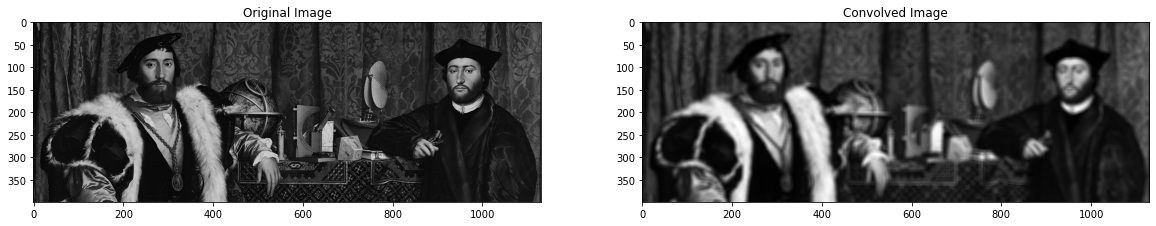

In [77]:
import numpy as np
from scipy.signal import convolve2d

im = Image.open('../img/CPR_1130x400.jpg').convert('L')  # Convert to grayscale
image_array = np.array(im)

# Define a kernel (filter)
kernel_size = 10
kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / kernel_size**2

# Perform 2D convolution using convolve2d from scipy.signal
result = convolve2d(image_array, kernel, mode='same', boundary='symm')

# Display the original and convolved images
plt.subplot(1, 2, 1)
plt.imshow(image_array, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(result, cmap='gray')
plt.title('Convolved Image')

plt.show()

✏️ Ici aussi modifiez la taille du kernel pour voir l’évolution du floutage

✏️ Testez le filtre [GaussianBlur](https://pillow.readthedocs.io/en/stable/reference/ImageFilter.html#PIL.ImageFilter.GaussianBlur)

## sharpen, smooth

Deux autres filtres sont souvent utilisés : *sharp* et *smooth*.  
- *sharp* accentue les contrastes et les détails  
- *smooth* est le contraire, il laisse les contrastes et uniformise les détails

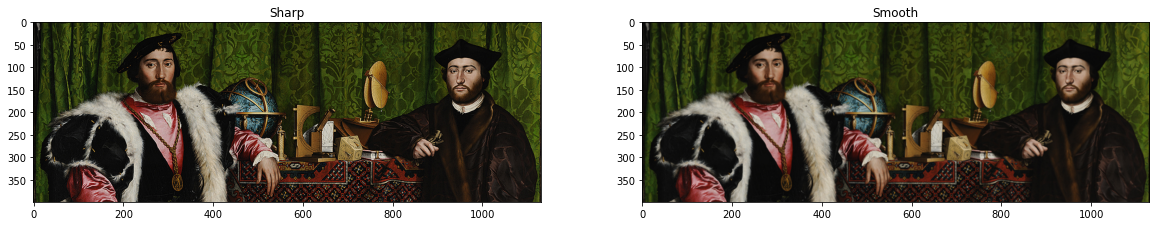

In [78]:
im = Image.open('../img/CPR_1130x400.jpg')
im_sharp = im.filter(ImageFilter.SHARPEN)
im_smooth = im.filter(ImageFilter.SMOOTH)

plt.subplot(1, 2, 1)
plt.imshow(im_sharp)
plt.title('Sharp')

plt.subplot(1, 2, 2)
plt.imshow(im_smooth)
plt.title('Smooth')

plt.show()

## Détection des contours

In [79]:
im_gray = im.convert("L")
edges = im_gray.filter(ImageFilter.FIND_EDGES)
edges.show()

Gtk-Message: 07:50:10.307: Failed to load module "colorreload-gtk-module"
Gtk-Message: 07:50:10.307: Failed to load module "window-decorations-gtk-module"


✏️ Utilisez `ImageFilter.EDGE_ENHANCE` sur les images modifiées avec un filtre *sharp* ou *smooth* pour voir la différence

## Seuillage (*thresholding*)

- Le seuillage est la technique la plus simple pour faire de la segmentation d’image
- Depuis un niveau de gris le seuillage permet de binariser une image



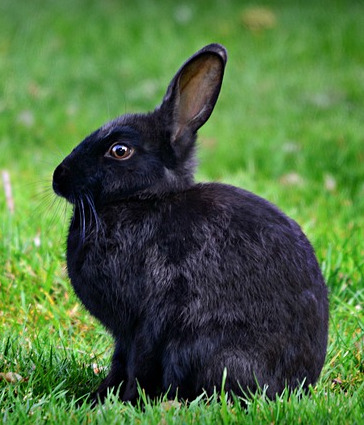

In [92]:
from IPython.display import display

im_rabbit = Image.open('../img/bunny.jpg')
display(im_rabbit)

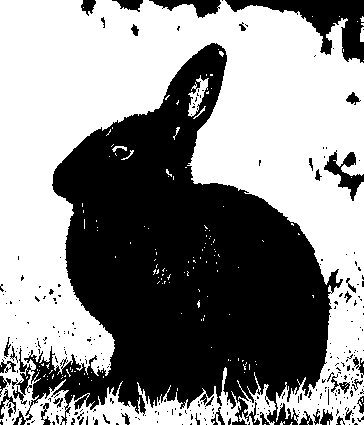

In [95]:
# passage en niveaux de gris
im_rabbit_gray = im_rabbit.convert("L")
threshold = 100 # définition du seuil

# seuillage avec point (https://pillow.readthedocs.io/en/stable/handbook/tutorial.html#point-operations)
im_rabbit_threshold = im_rabbit_gray.point(
    lambda x: 255 if x > threshold else 0
 )
display(im_rabbit_threshold)

✏️ Faîter varier la valeur du seuil pour voir les différences de traitement  

En général la zone que l’on souhaite segmenter est en blanc et le reste en noir  
✏️ Modifiez le code pour avoir la sélection en blanc

## Ajout d’un filigrane

Nous allons essayer d’ajouter un logo en filigrane (*watermark*) sur une image. Le logo en question : 

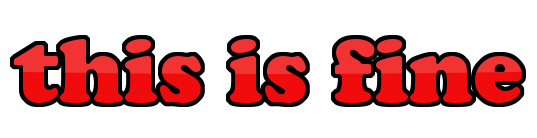

In [104]:
im_logo = Image.open('../img/fine.png')
display(im_logo)

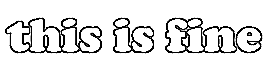

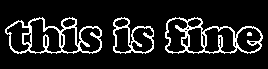

In [109]:
im_logo = Image.open('../img/fine.png')
im_logo = im_logo.convert("L") # niveaux de gris
threshold = 50
im_logo = im_logo.point(lambda x: 255 if x > threshold else 0) # seuillage
im_logo = im_logo.resize(
     (im_logo.width // 2, im_logo.height // 2)
 )
im_logo_contour = im_logo.filter(ImageFilter.CONTOUR) # contouring
display(im_logo_contour)

im_logo_inverse = im_logo_contour.point(lambda x: 0 if x == 255 else 255) # seuillage blanc sur noir
display(im_logo_inverse)

In [110]:
im = Image.open('../img/CPR_1130x400.jpg')
im.paste(im_logo_inverse, (480, 50), im_logo_inverse) # application du filtre sur l’image
im.show()

Gtk-Message: 08:32:19.335: Failed to load module "colorreload-gtk-module"
Gtk-Message: 08:32:19.335: Failed to load module "window-decorations-gtk-module"


## Différences entre deux images

Vous connaissez tous le jeu de trouver les différences entre deux images  
Nous allons essayer de le faire automatiquement


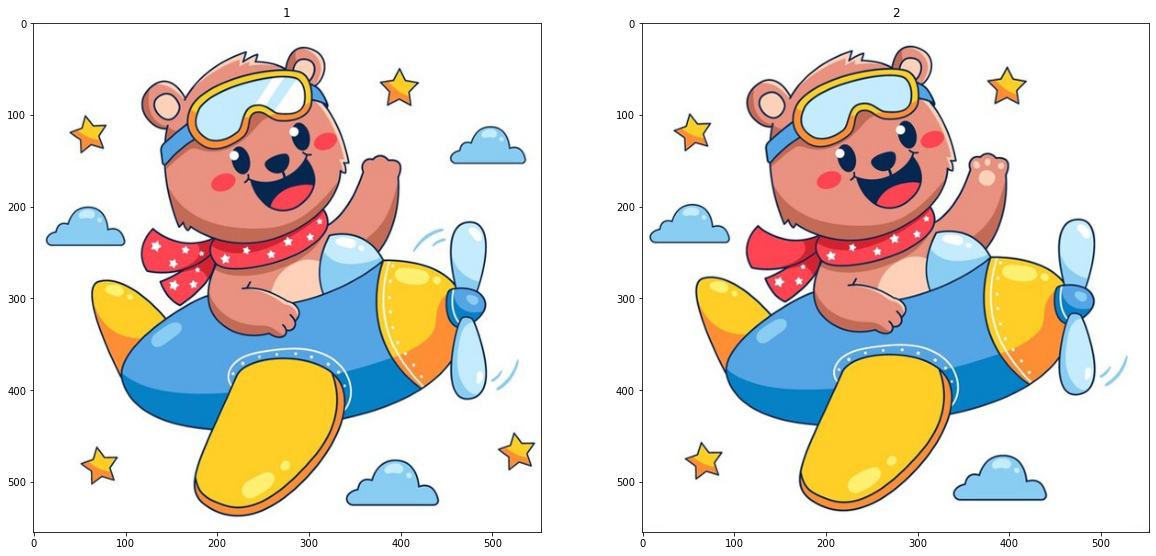

In [120]:
plane_1 = Image.open('../img/plane_1.jpg')
plane_2 = Image.open('../img/plane_2.jpg')

# Il faut que les deux images aient les mêmes dimensions
plane_1 = plane_1.resize((553, 555))
plane_2 = plane_2.resize((553, 555))

plt.subplot(1, 2, 1)
plt.imshow(plane_1)
plt.title('1')

plt.subplot(1, 2, 2)
plt.imshow(plane_2)
plt.title('2')

plt.show()

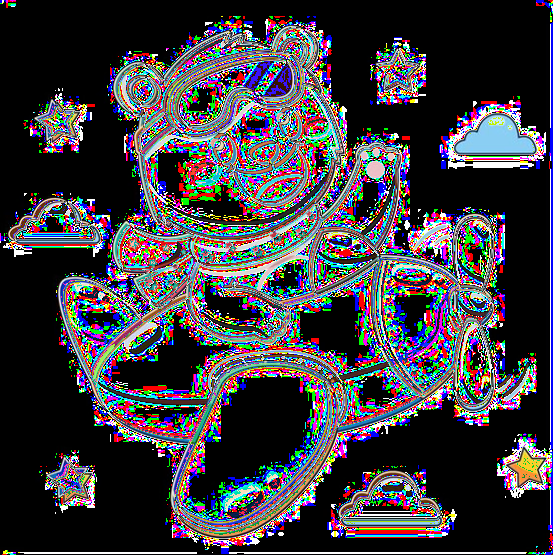

In [119]:
array_1 = np.asarray(plane_1)
array_2 = np.asarray(plane_2)
difference_array =  array_1 - array_2
difference = Image.fromarray(difference_array)
display(difference)